# Prétraitement des données — Dataset OASIS-1
## Introduction
Avant d'entraîner un modèle de deep learning, il est indispensable de préparer les données de manière rigoureuse. La qualité du prétraitement conditionne directement les performances du modèle — des données mal normalisées ou mal équilibrées peuvent conduire à un modèle biaisé ou peu généralisable, quelle que soit la complexité de l'architecture choisie.
## Objectifs de ce notebook
Ce notebook couvre les étapes de prétraitement appliquées aux images IRM du dataset OASIS-1, en vue de la classification des niveaux de démence en 4 classes :
ClasseDescriptionNonDementedAucun signe de démenceVeryMildDementedDémence très légèreMildDementedDémence légèreModerateDementedDémence modérée
## Les étapes réalisées sont les suivantes :

Chargement et organisation des données — lecture des images depuis leur répertoire, association avec leurs labels respectifs.
Redimensionnement — uniformisation de la taille des images pour les rendre compatibles avec l'entrée des modèles utilisés (EfficientNetB0 / ResNet50).
Normalisation — conversion des valeurs de pixels de [0, 255] vers [0, 1] en float32, pour stabiliser l'entraînement.
Gestion du déséquilibre des classes — analyse de la répartition des 40 000 images entre les 4 classes et mise en place de stratégies correctives si nécessaire (surpondération, augmentation ciblée).
Augmentation des données — application de transformations (rotation, flip, zoom...) pour enrichir artificiellement le dataset et améliorer la robustesse du modèle.
Découpage train / validation / test — séparation des données en trois ensembles distincts pour évaluer correctement les performances du modèle.

## Pourquoi ces étapes sont-elles importantes ?
Les IRM cérébrales sont des images médicales présentant des caractéristiques particulières — faible contraste entre les tissus, variabilité inter-individuelle, absence de couleur. Un prétraitement adapté permet de :

Réduire le bruit et standardiser les entrées du modèle.
Éviter le surapprentissage grâce à l'augmentation de données.
Garantir une évaluation fiable grâce à une séparation stricte des ensembles.

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from scipy import ndimage
from sklearn.mixture import GaussianMixture

In [5]:
inv = pd.read_csv("inventaire_oasis2.csv")
print(f"{len(inv)} sessions chargées depuis inventaire_oasis2.csv")

373 sessions chargées depuis inventaire_oasis2.csv


In [6]:
def load_averaged_volume(subject_path):
    """Charge tous les mpr-*.nifti.img d'une session et les moyenne."""
    img_files = sorted(glob.glob(os.path.join(subject_path, "**", "mpr-*.nifti.img"), recursive=True))
    if not img_files:
        raise FileNotFoundError(f"Aucun mpr-*.img trouvé dans {subject_path}")
    volumes = [np.squeeze(nib.load(f).get_fdata()) for f in img_files]
    header = nib.load(img_files[0]).header
    return np.mean(volumes, axis=0), header.get_zooms()[:3]

In [7]:
def simple_skull_strip(volume):
    """Retire le fond et le crâne par seuillage grossier. Approche simplifiée,
    moins précise qu'un outil dédié (FSL BET) mais sans dépendance externe."""
    threshold = threshold_otsu(volume[volume > 0])
    mask = volume > threshold
    # ne garder que la plus grande composante connexe (= le cerveau)
    labeled, n = ndimage.label(mask)
    if n > 0:
        sizes = ndimage.sum(mask, labeled, range(1, n + 1))
        largest = np.argmax(sizes) + 1
        mask = labeled == largest
    # dilatation légère pour ne pas trop rogner le cortex
    mask = ndimage.binary_dilation(mask, iterations=2)
    return mask

In [13]:
def segment_tissues(volume, brain_mask, n_classes=3, sample_size=50000):
    
    all_voxels = volume[brain_mask].reshape(-1, 1)
    rng = np.random.default_rng(0)
    sample_idx = rng.choice(len(all_voxels), size=min(sample_size, len(all_voxels)), replace=False)
    sample = all_voxels[sample_idx]
 
    gmm = GaussianMixture(n_components=n_classes, random_state=0).fit(sample)
    labels_flat = gmm.predict(all_voxels)  # predict sur tous les voxels reste rapide
 
    order = np.argsort(gmm.means_.flatten())
    remap = {old: new for new, old in enumerate(order)}
    labels_flat = np.array([remap[l] for l in labels_flat])
 
    seg = np.zeros(volume.shape, dtype=int)
    seg[brain_mask] = labels_flat + 1
    return seg
 
 
def compute_tissue_volumes(seg, voxel_dims):
    voxel_volume_mm3 = np.prod(voxel_dims)
    label_names = {1: "csf", 2: "gray_matter", 3: "white_matter"}
    volumes = {}
    for label, name in label_names.items():
        volumes[f"{name}_mL"] = np.sum(seg == label) * voxel_volume_mm3 / 1000.0
    return volumes

Sujet : OAS2_0001_MR1
Volumes calculés (mL) : {'csf_mL': np.float64(1261.80125), 'gray_matter_mL': np.float64(1548.0825), 'white_matter_mL': np.float64(818.34375)}


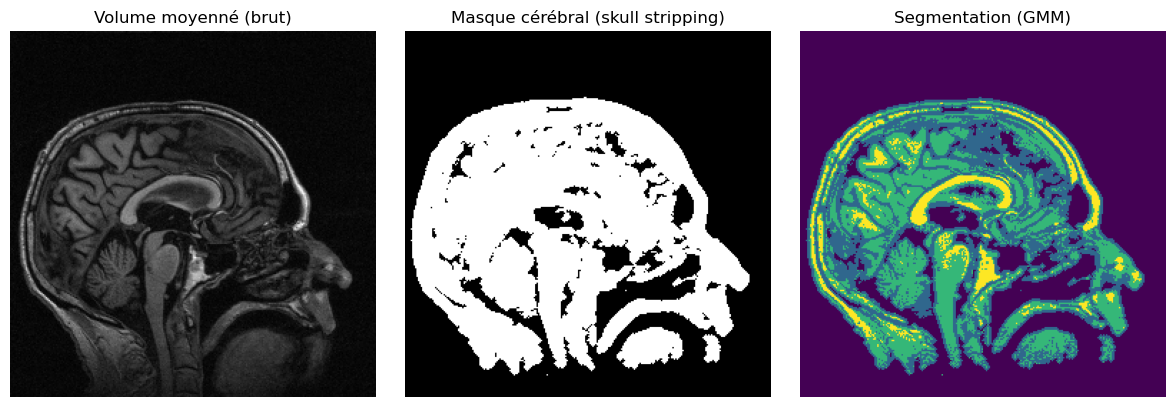

In [15]:
example = inv[inv["has_any_volume"]].iloc[0]
volume, voxel_dims = load_averaged_volume(example["path"])
brain_mask = simple_skull_strip(volume)
seg = segment_tissues(volume, brain_mask)
volumes = compute_tissue_volumes(seg, voxel_dims)
 
print("Sujet :", example["subject_id"])
print("Volumes calculés (mL) :", volumes)
 
z = volume.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(volume[:, :, z].T, cmap="gray", origin="lower")
axes[0].set_title("Volume moyenné (brut)")
axes[1].imshow(brain_mask[:, :, z].T, cmap="gray", origin="lower")
axes[1].set_title("Masque cérébral (skull stripping)")
axes[2].imshow(seg[:, :, z].T, cmap="viridis", origin="lower")
axes[2].set_title("Segmentation (GMM)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
def build_biomarker_table(inv_df):
    rows = []
    subset = inv_df[inv_df["has_any_volume"]].reset_index(drop=True)
    n = len(subset)
    for i, row in subset.iterrows():
        try:
            volume, voxel_dims = load_averaged_volume(row["path"])
            brain_mask = simple_skull_strip(volume)
            seg = segment_tissues(volume, brain_mask)
            volumes = compute_tissue_volumes(seg, voxel_dims)
            entry = {"subject_id": row["subject_id"]}
            entry.update(volumes)
            entry["total_brain_mL"] = volumes["gray_matter_mL"] + volumes["white_matter_mL"]
            rows.append(entry)
        except Exception as e:
            print(f"Erreur pour {row['subject_id']} : {e}")
        if (i + 1) % 20 == 0 or (i + 1) == n:
            print(f"  {i + 1}/{n} sessions traitées...")
    return pd.DataFrame(rows)
 
 
biomarkers = build_biomarker_table(inv)
print(f"\n{len(biomarkers)} sessions traitées avec succès.")
biomarkers.to_csv("biomarkers_tissue_volumes.csv", index=False)
print("Sauvegardé : biomarkers_tissue_volumes.csv")
biomarkers.head()

  20/373 sessions traitées...
  40/373 sessions traitées...
  60/373 sessions traitées...
  80/373 sessions traitées...
  100/373 sessions traitées...
  120/373 sessions traitées...
  140/373 sessions traitées...
  160/373 sessions traitées...
  180/373 sessions traitées...
  200/373 sessions traitées...
  220/373 sessions traitées...
  240/373 sessions traitées...
  260/373 sessions traitées...
  280/373 sessions traitées...
  300/373 sessions traitées...
  320/373 sessions traitées...
  340/373 sessions traitées...
  360/373 sessions traitées...
  373/373 sessions traitées...

373 sessions traitées avec succès.
Sauvegardé : biomarkers_tissue_volumes.csv


,subject_id,csf_mL,gray_matter_mL,white_matter_mL,total_brain_mL
0,OAS2_0001_MR1,1261.80125,1548.08250,818.34375,2366.42625
1,OAS2_0001_MR2,1329.17125,1217.05375,852.58250,2069.63625
2,OAS2_0002_MR1,1793.83125,1171.24625,508.27750,1679.52375
3,OAS2_0002_MR2,1494.36500,1023.76625,380.29875,1404.06500
4,OAS2_0002_MR3,1645.13125,1226.57250,389.89125,1616.46375
